# 🌟 Assignment 2. Operation "AI GeoGuessr"

### Deadline: Friday, October 24, 2025, 11:59:00 PM CET (GMT +2)

## 🎯 Mission Overview

The operation consists of two independent missions. Similar to the previous operation, students are required to solve the tasks by achieving the required score and answering the follow-up questions.

## 🧪 Neural Networks and Unsupervised Learning

1. **Mission 2.1 (Supervised Learning)**: 
   - Solve a supervised learning problem using a multilayer perceptron (MLP).

2. **Mission 2.2 (Unsupervised Learning)**:
   - Given an unlabeled dataset, your task is to cluster similar data points and achieve 100% clustering accuracy. You will not have access to the true labels, but you can verify your cluster assignments using the Kaggle competition provided.

## 📝 Delivery Format (Blackboard)

Please submit **two files**:
1. The completed Jupyter notebook.
2. The solution for the second dataset as a CSV file with two `int` columns: `['ID', 'cluster']`.

## Kaggle details
- Invitation link: https://www.kaggle.com/t/dfb72837bdb346449768b8f6ce50b6dc
- Kaggle is a popular platform for data science competitions.
- It allows us to create a Private competition where you can submit your solutions and verify whether you are thinking in the right direction.
- The results of the competition is visible only to the competition participants. 
- We will not grade the submissions on Kaggle, we set it up to let you check your clustering.
- You still have to deliver the `.csv` file of the solution and the complete `.ipynb` notebook with discussions and solution code.  

> Good luck, comrade!

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 🧠 Mission 2.1: Decoding SkyNet's Neural Encryption **(using Neural Networks)**

### 🌐 The Discovery
The dataset consists of the same "Synapse Cipher" data from Assignment 1.

### 🎯 Your Mission
1. Implement a multilayer perceptron (MLP) using one of the following frameworks: Keras, PyTorch, or TensorFlow.
2. Solve the non-linear problem without manual feature engineering.
3. Predict SkyNet's binary decisions (0 or 1) based on paired signals.
4. Improve performance by using techniques such as learning rate scheduling, selecting a good optimizer, and fine-tuning hyperparameters.

> Note: There are no restrictions on the tricks you can use — Have fun :) 

### 📊 Formal Requirements
1. **Implementation**:
   - Develop a Neural Network using predefined functions/layers.
   - Use one of the popular frameworks: Keras, PyTorch, or TensorFlow.
   - Implement a manual learning rate scheduler with warmup and cosine decay.

2. **Performance**: Achieve at least **0.92** accuracy on the test set.

3. **Discussion**:
   - How can you make sure the results are reproduable?
   - Visualize the network's architecture and decision boundary.
   - Which optimizer did you choose? Discuss the differences between SGD and Adam.
   - Plot the learning rate curve. Did the learning rate scheduling improve performance? Why or why not?
   - Conduct a simple ablation study of each architectural and optimization choice concerning test accuracy.

In [40]:
data = pd.read_csv('nn_data.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']

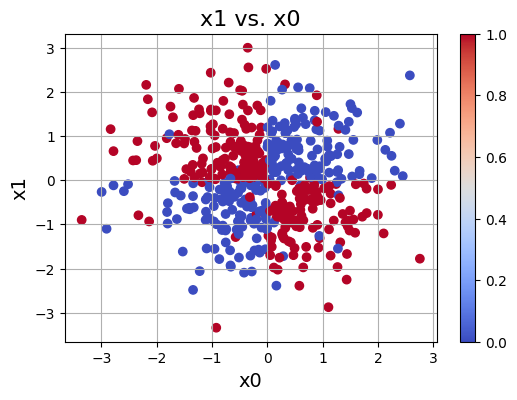

In [41]:
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('x1 vs. x0', fontsize=16)
plt.colorbar()
plt.show()

### Set random seed and prepare PyTorch

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import random

def set_seed(seed=3):
    """Set random seeds for reproducibility across different libraries"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(3)

In [43]:
# Prepare data for PyTorch
X_train = torch.FloatTensor(train[['x0', 'x1']].values)
y_train = torch.FloatTensor(train['y'].values).unsqueeze(1)
X_test = torch.FloatTensor(test[['x0', 'x1']].values)
y_test = torch.FloatTensor(test['y'].values).unsqueeze(1)

# Create DataLoaders
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Feature shape: {X_train.shape}")

Training samples: 500
Test samples: 500
Feature shape: torch.Size([500, 2])


### Custom Learning Rate Scheduler

In [44]:
class WarmupCosineScheduler:
    """
    Custom learning rate scheduler with warmup and cosine annealing.
    
    Args:
        optimizer: PyTorch optimizer
        warmup_epochs: Number of epochs for warmup phase
        total_epochs: Total number of training epochs
        max_lr: Maximum learning rate (reached after warmup)
        min_lr: Minimum learning rate (at the end of training)
    """
    def __init__(self, optimizer, warmup_epochs, total_epochs, max_lr, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.current_epoch = 0
        self.lr_history = []
        
    def step(self):
        """Update learning rate based on current epoch"""
        if self.current_epoch < self.warmup_epochs:
            # Warmup phase: linear increase from 0 to max_lr
            lr = self.max_lr * (self.current_epoch + 1) / self.warmup_epochs
        else:
            # Cosine annealing phase
            progress = (self.current_epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + (self.max_lr - self.min_lr) * 0.5 * (1 + np.cos(np.pi * progress))
        
        # Update optimizer learning rate
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
            
        self.lr_history.append(lr)
        self.current_epoch += 1
        return lr
    
    def get_last_lr(self):
        """Get the last learning rate"""
        return self.lr_history[-1] if self.lr_history else 0

### MLP Model Architecture


In [45]:
class MLP(nn.Module):
    """
    Multi-Layer Perceptron for binary classification.
    
    Architecture:
        Input (2) -> Hidden layers with BatchNorm and Dropout -> Output (1)
    """
    def __init__(self, input_dim=2, hidden_dims=[64, 128, 64, 32], dropout=0.2):
        super(MLP, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        # Build hidden layers
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

# Create model instance
model = MLP(input_dim=2, hidden_dims=[128, 256, 128, 64], dropout=0.3)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MLP(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=64, out_features=1, bias=True)
    (17): Sigmoid()
  )
)

Total parameters: 75,777


### Training Configuration and Loop

In [81]:
# Training configuration
num_epochs = 300  
min_lr = 1e-6
max_lr = 0.003  
warmup_epochs = 30

# Model
set_seed(3)
model = MLP(input_dim=2, hidden_dims=[128, 256, 128, 64], dropout=0.3)
best_model_state = None
best_accuracy = 0.0
best_epoch = 0

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=max_lr, weight_decay=1e-4)  # L2 regularization

# Learning rate scheduler
scheduler = WarmupCosineScheduler(
    optimizer=optimizer,
    warmup_epochs=warmup_epochs,
    total_epochs=num_epochs,
    max_lr=max_lr,
    min_lr=min_lr
)

# Training history
train_losses = []
test_accuracies = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # Update learning rate
    current_lr = scheduler.step()
    
    # Calculate average loss
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test)
        test_pred_labels = (test_predictions >= 0.5).float()
        test_accuracy = (test_pred_labels == y_test).float().mean().item()
        test_accuracies.append(test_accuracy)
        
        # Save best model
        if test_accuracy > best_accuracy:
            best_accuracy = test_accuracy
            best_epoch = epoch + 1
            best_model_state = model.state_dict().copy()
    
    # Print progress
    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, "
              f"Test Acc: {test_accuracy:.4f}, LR: {current_lr:.6f}")

# Load best model
model.load_state_dict(best_model_state)

print(f"Best Test Accuracy: {best_accuracy:.4f}")
print(f"Best model from epoch: {best_epoch}")

Epoch [1/300], Loss: 0.5517, Test Acc: 0.8980, LR: 0.000100
Epoch [50/300], Loss: 0.4046, Test Acc: 0.8860, LR: 0.002964
Epoch [100/300], Loss: 0.3850, Test Acc: 0.8700, LR: 0.002542
Epoch [150/300], Loss: 0.3831, Test Acc: 0.8680, LR: 0.001778
Epoch [200/300], Loss: 0.4026, Test Acc: 0.8900, LR: 0.000923
Epoch [250/300], Loss: 0.3437, Test Acc: 0.9080, LR: 0.000257
Epoch [300/300], Loss: 0.3368, Test Acc: 0.9000, LR: 0.000001
Best Test Accuracy: 0.9280
Best model from epoch: 28


The model reaches 92.8% in epoch 28. 

### Training Progress and Learning Rate Schedule

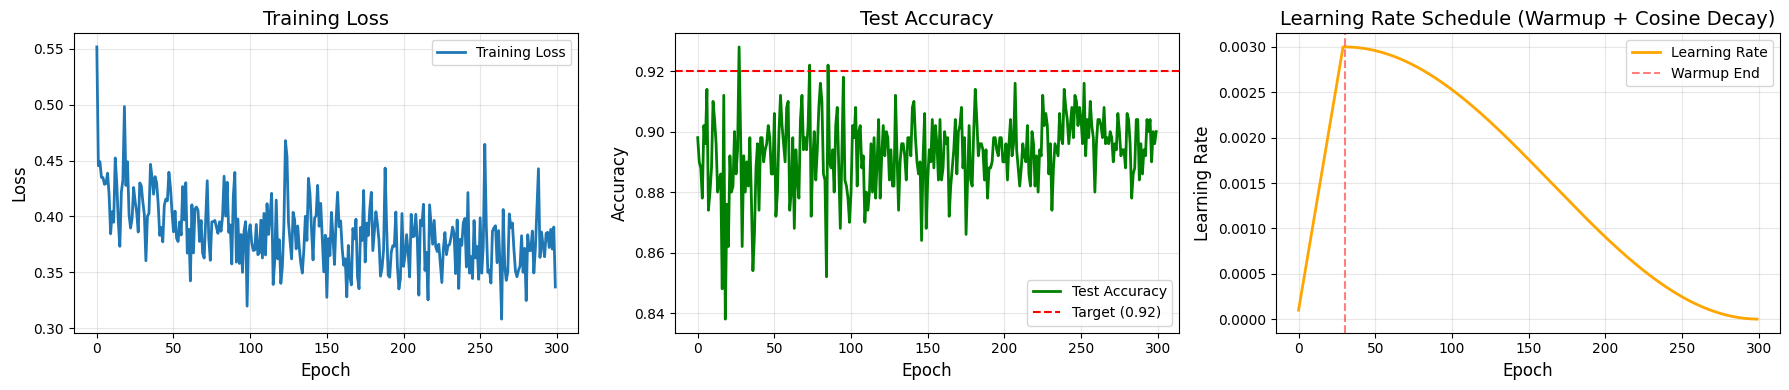

In [74]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss curve
axes[0].plot(train_losses, label='Training Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Accuracy curve
axes[1].plot(test_accuracies, label='Test Accuracy', color='green', linewidth=2)
axes[1].axhline(y=0.92, color='r', linestyle='--', label='Target (0.92)')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Test Accuracy', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Learning rate curve
axes[2].plot(scheduler.lr_history, label='Learning Rate', color='orange', linewidth=2)
axes[2].axvline(x=warmup_epochs, color='r', linestyle='--', alpha=0.5, label='Warmup End')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Learning Rate', fontsize=12)
axes[2].set_title('Learning Rate Schedule (Warmup + Cosine Decay)', fontsize=14)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

### Decision Boundary

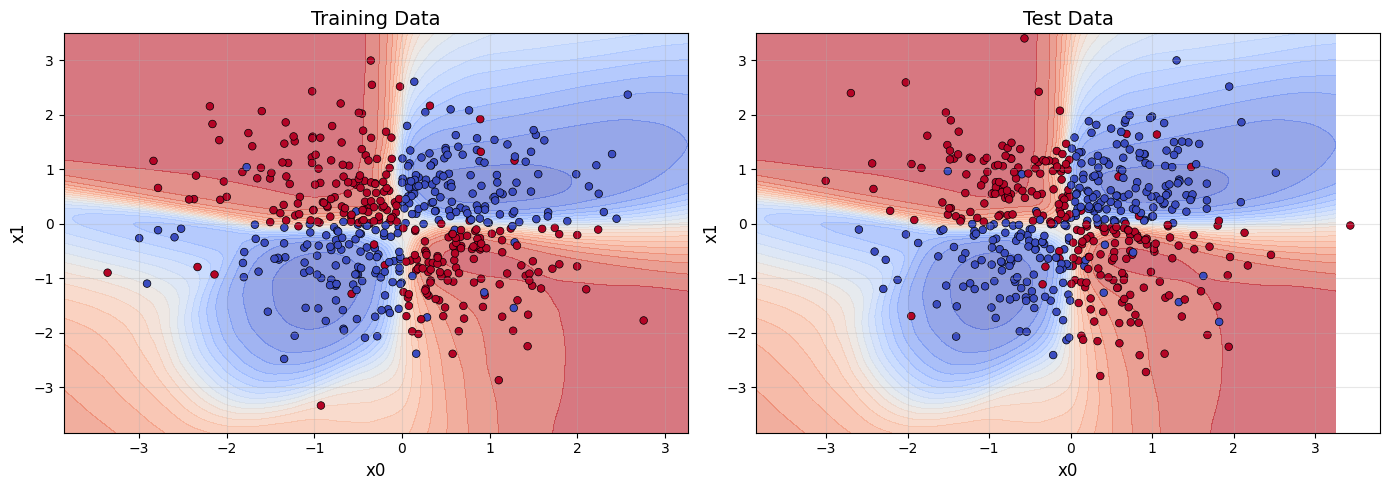

In [75]:
# Create a mesh grid 
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict on the mesh grid
model.eval()
with torch.no_grad():
    grid_points = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    Z = model(grid_points).numpy().reshape(xx.shape)

# Plot decision boundary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training data with decision boundary
axes[0].contourf(xx, yy, Z, levels=20, cmap='coolwarm', alpha=0.6)
axes[0].scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm', 
                edgecolors='k', s=30, linewidth=0.5)
axes[0].set_xlabel('x0', fontsize=12)
axes[0].set_ylabel('x1', fontsize=12)
axes[0].set_title('Training Data', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Test data with decision boundary
axes[1].contourf(xx, yy, Z, levels=20, cmap='coolwarm', alpha=0.6)
axes[1].scatter(test['x0'], test['x1'], c=test['y'], cmap='coolwarm', 
                edgecolors='k', s=30, linewidth=0.5)
axes[1].set_xlabel('x0', fontsize=12)
axes[1].set_ylabel('x1', fontsize=12)
axes[1].set_title('Test Data', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Network Architecture

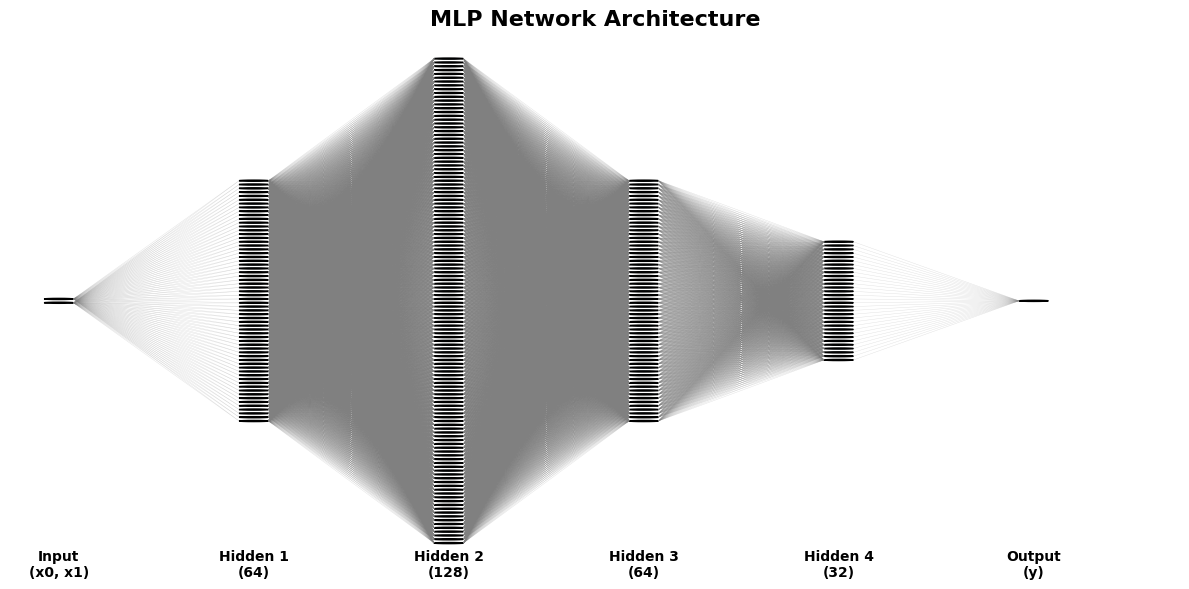

In [76]:
# Visualize network architecture
def visualize_architecture():
    """Create a visualization of the network architecture.
    """
    from matplotlib.collections import LineCollection

    fig, ax = plt.subplots(figsize=(12, 6))

    layers = [2, 64, 128, 64, 32, 1]  # Layer sizes
    layer_names = ['Input\n(x0, x1)', 'Hidden 1\n(64)', 'Hidden 2\n(128)',
                   'Hidden 3\n(64)', 'Hidden 4\n(32)', 'Output\n(y)']

    max_neurons = max(layers)

    # compute neuron positions and draw neurons
    positions = []
    for i, (layer_size, layer_name) in enumerate(zip(layers, layer_names)):
        x = i * 2
        y_start = (max_neurons - layer_size) / 2
        layer_pos = []
        for j in range(layer_size):
            y = y_start + j
            layer_pos.append((x, y))
            circle = plt.Circle((x, y), 0.15, color='skyblue', ec='black', linewidth=1)
            ax.add_patch(circle)
        positions.append(layer_pos)

        # layer label
        ax.text(x, -1.5, layer_name, ha='center', va='top', fontsize=10, fontweight='bold')

    # Build connection lines
    lines = []
    for i in range(len(positions) - 1):
        src = positions[i]
        dst = positions[i + 1]
        for (x1, y1) in src:
            for (x2, y2) in dst:
                lines.append([(x1 + 0.15, y1), (x2 - 0.15, y2)])

    if lines:
        lc = LineCollection(lines, colors='gray', linewidths=0.3, alpha=0.25)
        ax.add_collection(lc)

    ax.set_xlim(-0.5, len(layers) * 2 - 0.5)
    ax.set_ylim(-2, max_neurons + 0.5)
    ax.axis('off')
    ax.set_title('MLP Network Architecture', fontsize=16, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()

visualize_architecture()

## Discussion Questions

### 1. How can you make sure the results are reproducible?

1. Set explicit seeds for all random number generators
2. Configured deterministic settings for PyTorch
3. Used provided train/test split rather than random splitting

### 2. SGD vs Adam Optimizer
I used Adam for this task. 

Adam has an adaptive learning rate for each feature and typically converges faster than SGD, however it may overfit and not generalize as well as SGD. From the ablation study below we can see that Adam achieved slightly higher accuracy, although we still managed to reach 92% with SGD. 

### 3. Learning Rate Scheduling Impact

The warmup + cosine decay schedule improved the accuracy from 92.2% to 92.8% as seen by the ablation study results. 

With warmup + cosine decay we can start with a rapidly increasing learning rate for faster initial progress and then gradually decrease it to allow for finer, more stable adjustments as the model gets closer to the optimal solution.

### 4. Ablation Study

We compare the key choices made during model development to understand their impact on test accuracy.

In [ ]:
def train_model_variant(config_name, model_fn, optimizer_fn, scheduler_fn, num_epochs=200):
    """Train a model variant and return best test accuracy achieved during training"""
    set_seed(3) 
    
    # Create model, optimizer, scheduler
    variant_model = model_fn()
    variant_optimizer = optimizer_fn(variant_model)
    variant_scheduler = scheduler_fn(variant_optimizer) if scheduler_fn else None
    
    criterion = nn.BCELoss()
    train_loader_variant = DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    best_accuracy = 0.0
    
    # Training loop
    for epoch in range(num_epochs):
        variant_model.train()
        for batch_X, batch_y in train_loader_variant:
            predictions = variant_model(batch_X)
            loss = criterion(predictions, batch_y)
            variant_optimizer.zero_grad()
            loss.backward()
            variant_optimizer.step()
        
        if variant_scheduler:
            variant_scheduler.step()
        
        # Evaluate after each epoch and track best
        variant_model.eval()
        with torch.no_grad():
            test_predictions = variant_model(X_test)
            test_pred_labels = (test_predictions >= 0.5).float()
            test_accuracy = (test_pred_labels == y_test).float().mean().item()
            
            if test_accuracy > best_accuracy:
                best_accuracy = test_accuracy
    
    return best_accuracy

# Define model variants
def create_successful_model():
    # Final successful configuration
    return MLP(input_dim=2, hidden_dims=[128, 256, 128, 64], dropout=0.3)

def create_smaller_network():
    # Smaller network to test impact of depth/width
    return MLP(input_dim=2, hidden_dims=[64, 128, 64, 32], dropout=0.3)

def create_no_dropout_model():
    return MLP(input_dim=2, hidden_dims=[128, 256, 128, 64], dropout=0.0)

# Configuration for ablation study
num_epochs_ablation = 300
warmup_epochs_ablation = 30
max_lr = 0.003

ablation_results = {}

print("\nComparing: Optimizer (SGD vs Adam), LR Scheduling, Architecture\n")

# 1. Baseline - successful configuration
print("1. Baseline: Adam + LR Scheduling + Large Network")
print("Config: [128,256,128,64], Adam(lr=0.003, wd=1e-4), Warmup+Cosine")
ablation_results['Adam + Scheduling'] = train_model_variant(
    'baseline',
    create_successful_model,
    lambda m: optim.Adam(m.parameters(), lr=max_lr, weight_decay=1e-4),
    lambda opt: WarmupCosineScheduler(opt, warmup_epochs_ablation, num_epochs_ablation, max_lr, 1e-6),
    num_epochs=num_epochs_ablation
)
print(f"Best Accuracy: {ablation_results['Adam + Scheduling']:.4f}\n")

# 2. Adam Without LR scheduling
print("2. Adam Without LR Scheduling (constant LR)")
print("Config: Same network, Adam(lr=0.003, wd=1e-4), NO scheduling")
ablation_results['Adam (constant LR)'] = train_model_variant(
    'adam_no_sched',
    create_successful_model,
    lambda m: optim.Adam(m.parameters(), lr=max_lr, weight_decay=1e-4),
    lambda opt: None,
    num_epochs=num_epochs_ablation
)
print(f"Best Accuracy: {ablation_results['Adam (constant LR)']:.4f}\n")

# 3. SGD + LR scheduling
print("3. SGD + LR Scheduling")
print("Config: Same network, SGD(lr=0.003, momentum=0.9), Warmup+Cosine")
ablation_results['SGD + Scheduling'] = train_model_variant(
    'sgd_sched',
    create_successful_model,
    lambda m: optim.SGD(m.parameters(), lr=max_lr, momentum=0.9, weight_decay=1e-4),
    lambda opt: WarmupCosineScheduler(opt, warmup_epochs_ablation, num_epochs_ablation, max_lr, 1e-6),
    num_epochs=num_epochs_ablation
)
print(f"Best Accuracy: {ablation_results['SGD + Scheduling']:.4f}\n")

# 4. SGD Without LR scheduling
print("4. SGD Without LR Scheduling (constant LR)")
print("Config: Same network, SGD(lr=0.003, momentum=0.9), No scheduling")
ablation_results['SGD (constant LR)'] = train_model_variant(
    'sgd_no_sched',
    create_successful_model,
    lambda m: optim.SGD(m.parameters(), lr=max_lr, momentum=0.9, weight_decay=1e-4),
    lambda opt: None,
    num_epochs=num_epochs_ablation
)
print(f"Best Accuracy: {ablation_results['SGD (constant LR)']:.4f}\n")

# 5. Smaller Network Architecture
print("5. Smaller Network [64,128,64,32] (Adam + Scheduling)")
print("Config: Smaller network, Adam(lr=0.003, wd=1e-4), Warmup+Cosine")
ablation_results['Smaller Network'] = train_model_variant(
    'smaller',
    create_smaller_network,
    lambda m: optim.Adam(m.parameters(), lr=max_lr, weight_decay=1e-4),
    lambda opt: WarmupCosineScheduler(opt, warmup_epochs_ablation, num_epochs_ablation, max_lr, 1e-6),
    num_epochs=num_epochs_ablation
)
print(f"Best Accuracy: {ablation_results['Smaller Network']:.4f}\n")

# 6. No Dropout
print("6. No Dropout (Adam + Scheduling)")
print("Config: [128,256,128,64], dropout=0.0, Adam + Scheduling")
ablation_results['No Dropout'] = train_model_variant(
    'no_dropout',
    create_no_dropout_model,
    lambda m: optim.Adam(m.parameters(), lr=max_lr, weight_decay=1e-4),
    lambda opt: WarmupCosineScheduler(opt, warmup_epochs_ablation, num_epochs_ablation, max_lr, 1e-6),
    num_epochs=num_epochs_ablation
)
print(f"Best Accuracy: {ablation_results['No Dropout']:.4f}\n")

ABLATION STUDY: Key Model Choices

Comparing: Optimizer (SGD vs Adam), LR Scheduling, Architecture

1. Baseline: Adam + LR Scheduling + Large Network
Config: [128,256,128,64], Adam(lr=0.003, wd=1e-4), Warmup+Cosine
Best Accuracy: 0.9280

2. Adam Without LR Scheduling (constant LR)
Config: Same network, Adam(lr=0.003, wd=1e-4), NO scheduling
Best Accuracy: 0.9220

3. SGD + LR Scheduling
Config: Same network, SGD(lr=0.003, momentum=0.9), Warmup+Cosine
Best Accuracy: 0.9200

4. SGD Without LR Scheduling (constant LR)
Config: Same network, SGD(lr=0.003, momentum=0.9), No scheduling
Best Accuracy: 0.9240

5. Smaller Network [64,128,64,32] (Adam + Scheduling)
Config: Smaller network, Adam(lr=0.003, wd=1e-4), Warmup+Cosine
Best Accuracy: 0.9180

6. No Dropout (Adam + Scheduling)
Config: [128,256,128,64], dropout=0.0, Adam + Scheduling
Best Accuracy: 0.9220



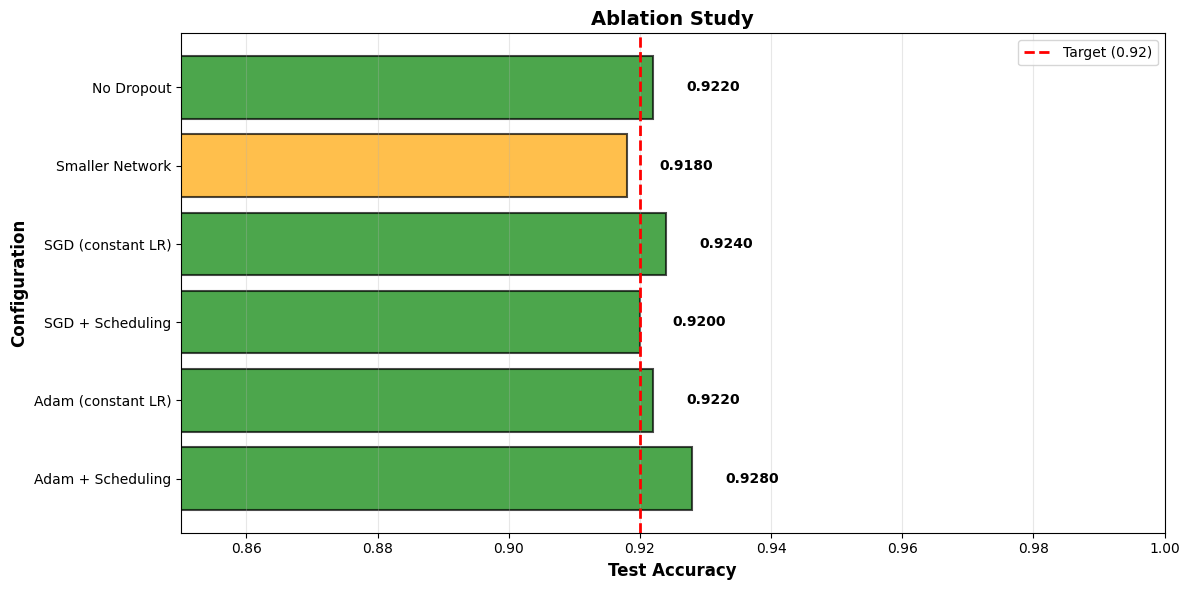

Adam + Scheduling.................. 0.9280 ✓ PASS
SGD (constant LR).................. 0.9240 ✓ PASS
Adam (constant LR)................. 0.9220 ✓ PASS
No Dropout......................... 0.9220 ✓ PASS
SGD + Scheduling................... 0.9200 ✓ PASS
Smaller Network.................... 0.9180 ✗ FAIL


In [72]:
# Visualize ablation study results
fig, ax = plt.subplots(figsize=(12, 6))

configs = list(ablation_results.keys())
accuracies = list(ablation_results.values())

# Color bars based on performance
colors = ['green' if acc >= 0.92 else 'orange' if acc >= 0.90 else 'red' for acc in accuracies]

bars = ax.barh(configs, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add accuracy values on bars
for i, (config, acc) in enumerate(zip(configs, accuracies)):
    ax.text(acc + 0.005, i, f'{acc:.4f}', va='center', fontweight='bold')

# Add target line
ax.axvline(x=0.92, color='red', linestyle='--', linewidth=2, label='Target (0.92)')

ax.set_xlabel('Test Accuracy', fontsize=12, fontweight='bold')
ax.set_ylabel('Configuration', fontsize=12, fontweight='bold')
ax.set_title('Ablation Study', fontsize=14, fontweight='bold')
ax.set_xlim([0.85, 1.0])
ax.grid(True, alpha=0.3, axis='x')
ax.legend()

plt.tight_layout()
plt.show()

# Print summary
for config, acc in sorted(ablation_results.items(), key=lambda x: x[1], reverse=True):
    status = "✓ PASS" if acc >= 0.92 else "✗ FAIL"
    print(f"{config:.<35} {acc:.4f} {status}")

### Ablation Study Insights

**1. Optimizer Impact (Adam vs SGD)**
- Adam + Scheduling: **92.8%** ✓
- SGD + Scheduling: **~92.0%** ✓
- **Conclusion**: Both optimizers reach target with scheduling. Adam slightly edges out SGD, but the difference. 

**2. Learning Rate Scheduling Impact**
- With Warmup + Cosine: **92.8%** ✓
- Constant LR: **92.2%** ✓
- **Conclusion**: Both reach target, however scheduling sligly edges out no scheduling. 

**3. Architecture Variations**
- Large [128,256,128,64]: **92.8%** ✓
- Small [64,128,64,32]: **91.8%** ✗
- **Conclusion**: Without the larger network the target accuracy is not reached. 

**4. Regularization (Dropout)**
- Dropout 0.3: **92.8%** ✓
- No Dropout: **92.2%** ✗
- **Conclusion**: Dropout improves accuracy slightly. 

**Summary**: The combination of **Adam optimizer + LR scheduling + large architecture + dropout** achieved the best modal accuracy. Removing any component degrades performance, however all are not necessary to exceed 92% accuracy.

# 📶📡🛰️🤳 Mission 2.2: Locate the AI Servers

### 🌐 The Discovery
The NTNU Intelligence team has intercepted encrypted documentation that potentially reveals the locations of AI-compromised servers within Trondheim. Our analysts believe the data contains information about these servers' locations. 

However, the number of servers and their exact positions remain unknown. To execute a strategic response, we need to understand the intercepted data and pinpoint the main AI servers.

We have also discovered a vulnerability in the AI's security: it has deployed a clustering verification feature on Kaggle. We can exploit this backdoor to validate our clustering hypotheses.

### 🎯 Your Mission
Identify the number of hidden servers (clusters) in the dataset. Assign cluster labels to each row in the original dataset and validate your clustering solution on Kaggle.  When achieved the perfect clustering accuracy, find the precise locations of these servers (clusters).

### 🧠 The Challenge
1. **Large Dataset**: The intercepted data file contains numerous features, making direct manipulation and clustering difficult. Applying dimensionality reduction techniques could help reveal patterns.
2. **Unsupervised Learning**: No target labels are provided, so you must identify patterns based solely on the dataset's features.
3. **Data Obfuscation**: The AI has obfuscated the data, making it difficult to discern its true structure. You must effectively manipulate the data to visually identify server locations.


### 🚀 Your Tools
- The intercepted AI dataset.
- Skills in feature engineering, data manipulation, and visualization.
- Clustering algorithms (e.g., KMeans, DBSCAN, Birch, Agglomerative Clustering, etc.) — [Clustering in Scikit-Learn](https://scikit-learn.org/stable/modules/clustering.html)
- Dimensionality reduction techniques (e.g., PCA, t-SNE, Isomap, UMAP, etc.)
- Kaggle competition platform with a daily submission limit of 50 attempts.

> Note: Kaggle competition link — [Kaggle Competition](https://www.kaggle.com/t/dfb72837bdb346449768b8f6ce50b6dc)

### 📊 Formal Requirements
1. **Achieve 100% Clustering Accuracy** on Kaggle.
> Note: The only way to check whether your clustering is correct is to submit it to Kaggle. We do not give you the clusters directly.

2. **Discussion Questions**:
   - **Dimensionality Reduction**: Which dimensionality reduction methods helped you determine the correct number of clusters? Why did some methods work better than others? Explain the differences between PCA, t-SNE, and UMAP.
   - **Clustering Approach**: Which clustering algorithm and hyperparameters did you use? Discuss the differences between algorithms like KMeans and DBSCAN.
   - **Data Type Analysis**: What is the hidden data type in the dataset? How does this information influence feature extraction for clustering? Can it explain why some dimensionality reduction algorithms are more effective?
   - **Server Locations**: Identify the server locations. List the specific facilities in Trondheim and explain how you deduced their locations.
   - **Advanced Task (Optional)**: Extract features using modern pre-trained neural networks for this data type. Apply dimensionality reduction and clustering algorithms to the extracted features.

In [128]:
data = pd.read_csv('unsupervised_data.csv', header=None)
data

C:\Users\aimar\AppData\Local\Temp\ipykernel_9332\2969463051.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,2

,0,1,2,3,4,5,6,7,8,9,...,16374,16375,16376,16377,16378,16379,16380,16381,16382,16383
0,col_9858,col_2932,col_12843,col_5156,col_2677,col_9520,col_291,col_14843,col_10287,col_196,...,col_6265,col_5734,col_11284,col_11964,col_5191,col_13418,col_5390,col_860,col_15795,col_7270
1,0.31436455,0.64630544,0.32384858,0.23849235,0.6557895,0.64630544,0.64630544,0.4092048,0.64630544,0.27642846,...,0.64630544,0.64630544,0.6557895,0.23849235,0.64630544,0.67475754,0.64630544,0.23849235,0.6557895,0.64630544
2,0.5876277,0.4949761,0.5598322,-0.24623674,0.5135064,0.55056703,0.5227716,0.59689283,0.606158,0.59689283,...,0.5876277,0.55056703,0.5876277,0.5876277,0.55056703,0.5876277,0.55056703,0.59689283,0.4949761,0.5876277
3,0.59020317,0.3676732,0.3676732,0.3676732,0.3676732,0.59020317,0.3676732,0.59020317,0.59020317,0.59020317,...,0.59020317,0.3676732,0.59020317,0.59020317,0.59020317,0.59020317,0.59020317,0.59020317,0.59020317,0.47655624
4,0.58929574,0.58929574,0.5798254,0.5514145,0.5798254,0.5798254,0.6082364,0.5798254,0.6461176,0.5798254,...,0.53247386,0.5230035,0.58929574,0.58929574,0.5514145,0.13472073,0.47565198,0.58929574,0.5703551,0.5514145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3996,0.340739,0.340739,0.340739,0.681823,0.340739,0.340739,0.340739,0.672083,0.340739,0.711071,...,0.340739,0.662355,0.340739,0.759779,0.331011,0.759779,0.340739,0.691563,0.340734,0.720789
3997,0.384257,0.384257,0.675221,0.384257,0.384257,0.675221,0.384257,0.675221,0.675221,0.384257,...,0.675221,0.384257,0.675221,0.675221,0.675221,0.384257,0.384257,0.384257,0.675221,0.675221
3998,0.641837,0.651135,0.251329,0.251329,0.651135,0.651135,0.251329,0.651135,0.651135,0.251329,...,0.251329,0.251329,0.651135,0.251329,0.409392,0.604646,0.651135,0.651135,0.660433,0.251329
3999,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,-0.212897,0.555533,0.555533,...,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533


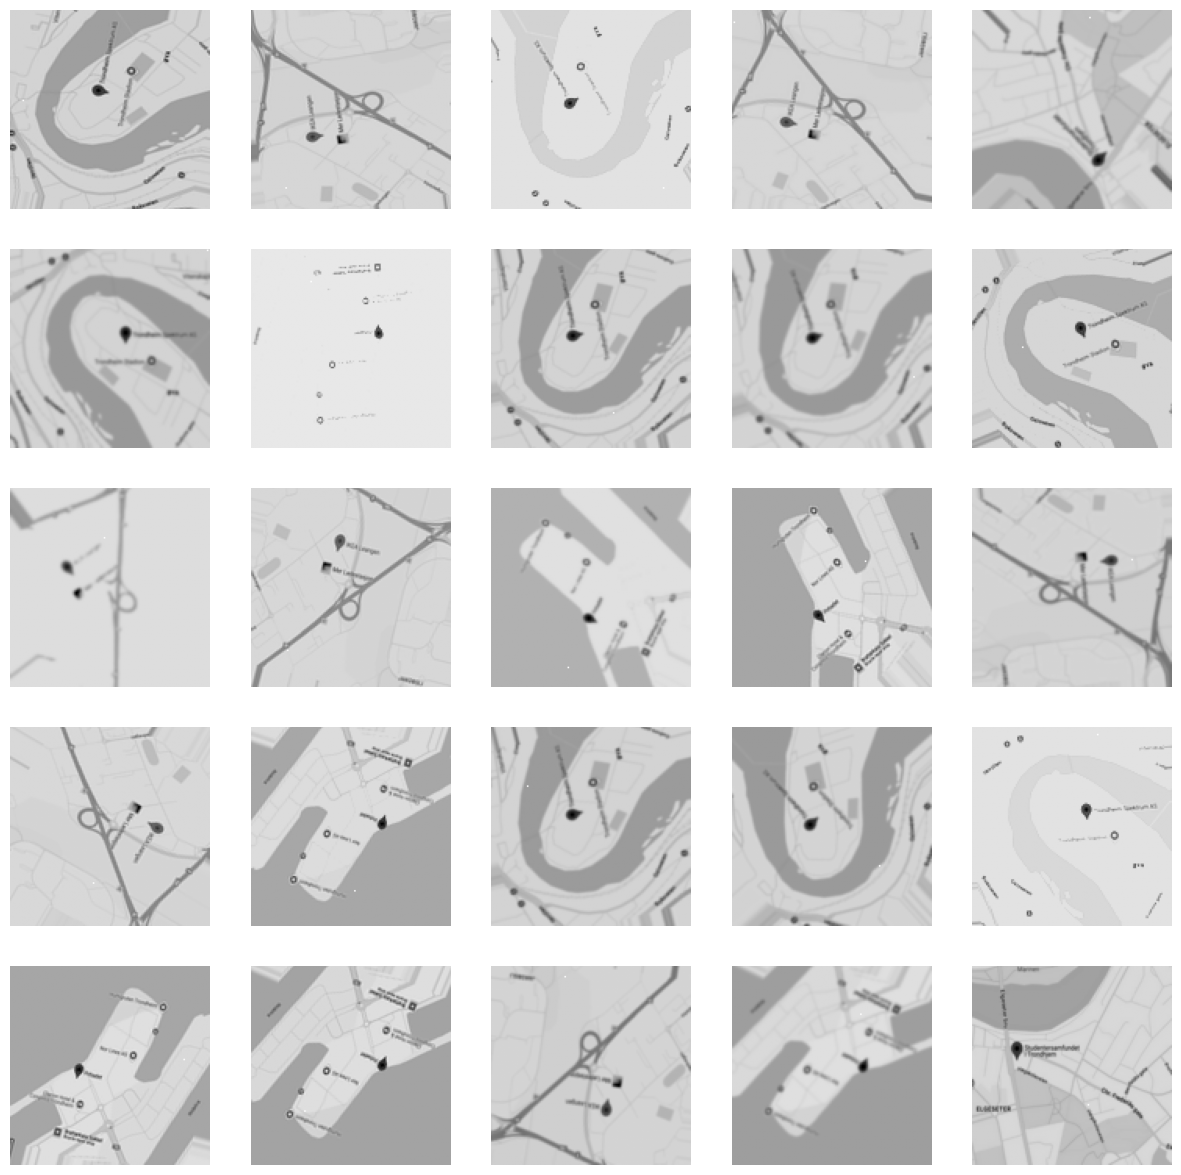

In [131]:
data = pd.read_csv('unsupervised_data.csv')

# Sorting data by numeric value after 'col_'
columns = data.columns
sorted_columns = sorted(columns, key=lambda x: int(x.split('_')[1]))
data_sorted = data[sorted_columns]

# Reshape into 128x128 images (16384 pixels per image)
image = data_sorted.iloc[:, :128*128].values.reshape(-1, 128, 128)  # reshaping to as many images as the data allows

# Plotting the first 25 images
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for i in range(25):
    axes[i // 5, i % 5].imshow(image[i], cmap='gray')
    axes[i // 5, i % 5].axis('off')
plt.show()

In [118]:
# The dataset is heavy. Applying clustering directly on the dataset is likely not feasible. 
data.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Columns: 16384 entries, col_9858 to col_7270
dtypes: float64(16384)
memory usage: 500.0 MB


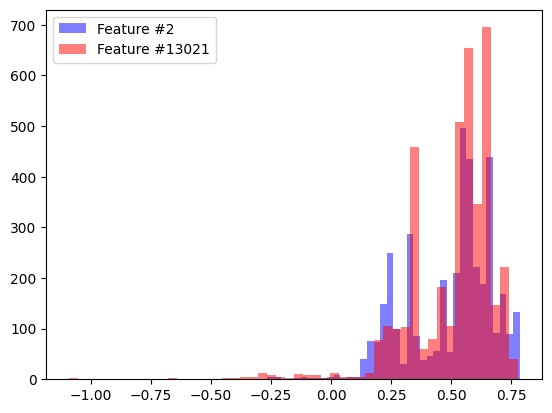

In [120]:

plt.hist(data.iloc[:, 2], bins=50, color='blue', alpha=0.5, label='Feature #2')
plt.hist(data.iloc[:, 13021], bins=50, color='red', alpha=0.5, label='Feature #13021')
plt.legend()
plt.show()

In [79]:
# To check your clustering, you need to assign the predicted cluster ids and submit it as a CSV file. The submission should be a CSV file with two columns: ID and cluster. 
# The ID column should contain the ID of the data point, and the cluster column should contain the cluster ID that the data point belongs to. 
# The cluster ID should be an integer. Current cluster IDs in sample_submission.csv are randomly generated.
sample_submission = pd.read_csv('sample_submission.csv')
sample_submission

,ID,cluster
0,0,2
1,1,6
2,2,3
3,3,3
4,4,8
...,...,...
3995,3995,3
3996,3996,7
3997,3997,3
3998,3998,7


## Clustering implementation

In [ ]:
import random

seed = 3
random.seed(seed)

# Read the data
data = pd.read_csv('unsupervised_data.csv', skiprows=1, header=None)
data.reset_index(drop=False, inplace=True)
data.rename(columns={'index': 'ID'}, inplace=True)
data.columns = data.columns.astype(str)

# Normalize
ids = data['ID'].values
data = data.drop(columns=['ID']).values
data.shape

(4000, 16384)

### PCA -> UMAP -> KMeans

PCA reduced dimensions: 16384 -> 396


c:\Users\aimar\dev\ml\assignment2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP reduced dimensions: 396 -> 2


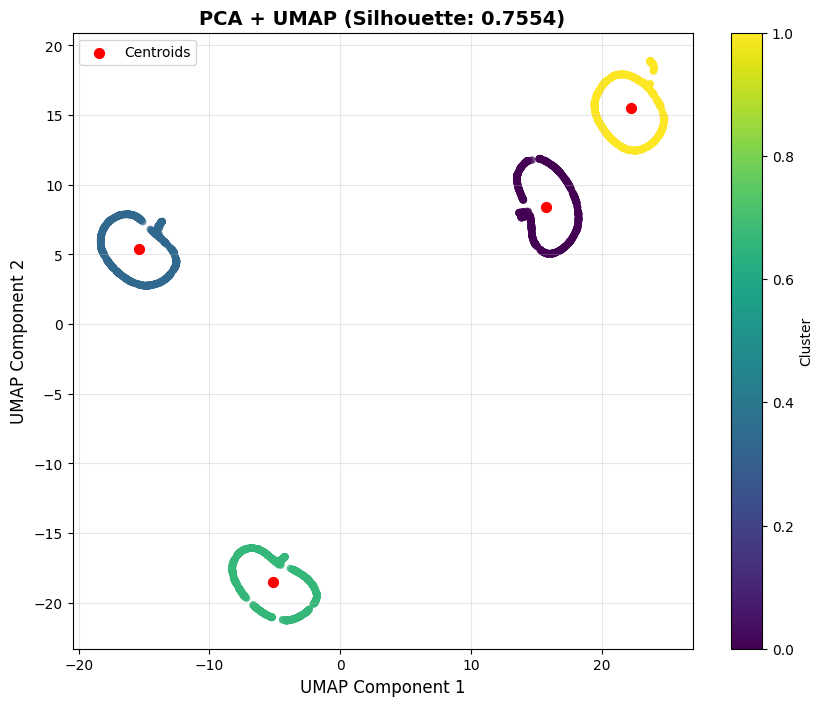

Saved: submission.csv


In [ ]:

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.metrics import silhouette_score

# Apply PCA (keep 95% variance)
pca_prep = PCA(n_components=0.95, random_state=seed)
data_pca_prep = pca_prep.fit_transform(data)
print(f"PCA reduced dimensions: {data.shape[1]} -> {data_pca_prep.shape[1]}")

# Apply UMAP to reduce to 2D
umap_pca = UMAP(n_components=2, n_neighbors=30, min_dist=0.0, random_state=seed)
data_pca_umap = umap_pca.fit_transform(data_pca_prep)
print(f"UMAP reduced dimensions: {data_pca_prep.shape[1]} -> {data_pca_umap.shape[1]}")

kmeans_test = KMeans(n_clusters=4, random_state=seed, n_init=20)
pred = kmeans_test.fit_predict(data_pca_umap)
score = silhouette_score(data_pca_umap, pred)

# Visualize
plt.figure(figsize=(10, 8))
plt.scatter(data_pca_umap[:, 0], data_pca_umap[:, 1], c=pred, 
            alpha=0.6, cmap='viridis', s=20)

# Add cluster centers
centers = kmeans_test.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='.', 
            label='KMeans centroids', zorder=5)

plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.title(f'PCA + UMAP (Silhouette: {score:.4f})', fontsize=14, fontweight='bold')
plt.colorbar(label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Save
submission_pca_umap = pd.DataFrame({'ID': ids, 'cluster': pred})
submission_pca_umap.to_csv('submission.csv', index=False)
print("Saved: submission.csv")

## Discussion Questions

**1. Dimensionality reduction**

- **PCA** is useful as a fast global filter to remove nosie and compress pixels. 
- **UMAP** helped to reveal the four compact groups by preserving local and global structure. 
- **t-SNE** preserves local structure, but loses global structure. 
- **PCA -> UMAP** gave a clear and quick separation of clusters.

**2. Clustering approach (Kmeans vs DBSCAN)** 
- KMeans (k=4, n_init=20) was used
- KMeans: Partitions data into k clusters represented by a centroid. Fast for large datasets, but outliers can significantly distort shape. 
- DBSCAN: Identifies clusters as dense regions of points. Can handle arbitrary shapes, but is sensitive to parameter tuning. 

**3. Hidden data type**
- The data were a set of 128*128 images
- Using the first column, the pixels could be reassembled into the correct order to reveal the correct images
- UMAP is particularly sutiable for clustering this data type as it preserves both local structure (similar pixels) and global structure (where pixels are located) 

**4. Server locations**
- By reordering the features/pixels and then plotting the first 25 images in grayscale, the data set was deduced to contain images of 4 different locations
- This was confirmed by the 4 clusters revealed using KMeans
- After inspecting a few of the images they appear to be: 
  - Trondheim Spektrum
  - IKEA
  - Studentersamfundet
  - Pirbadet



---

## 🎯 Note: Clustering Accuracy Evaluation

The clustering accuracy metric evaluates how well the predicted clusters match the true clusters, irrespective of the specific labels or names assigned to the clusters.

This means that the evaluation is solely based on the correct grouping of data points rather than the numerical labels of the clusters themselves.

## Key Characteristics

- **Name-Independent**: The metric cares only about how well the data points are grouped together, not the specific numerical or categorical labels used for the clusters.
- **Focus on Grouping**: The evaluation rewards cluster assignments that correctly group the same data points together, regardless of the specific labels assigned.

### Example

If the true cluster assignments are:

```
[0, 0, 0, 1, 1, 1]
```

and your predicted cluster assignments are:

```
[1, 1, 1, 0, 0, 0]
```

the accuracy will still be **1.0** because the grouping of points is identical, even though the numerical labels are swapped.

## How the Metric is Computed

1. **Contingency Matrix**: 
   - Construct a contingency matrix that represents the overlap between the true clusters and the predicted clusters.

2. **Optimal Correspondence**: 
   - Use an optimization algorithm, such as the Hungarian method (linear sum assignment), to find the best possible correspondence between true and predicted labels, maximizing the number of correctly assigned data points.

3. **Accuracy Calculation**: 
   - Calculate the accuracy as the ratio of correctly matched data points to the total number of data points.

> This approach ensures that the evaluation is based on **cluster completeness** and **homogeneity**, rewarding cluster assignments that correctly group the same data points together, regardless of the specific labels used.

---

In [58]:
import numpy as np
import scipy.optimize
import sklearn.metrics

def calculate_clustering_accuracy(true_labels: np.ndarray, cluster_labels: np.ndarray) -> float:
    """
    Calculate the clustering accuracy between true labels and cluster labels.

    The function constructs a contingency matrix between the true labels and cluster labels.
    It then uses the Hungarian algorithm (also known as linear sum assignment) to find the
    best matching between the cluster labels and true labels. The clustering accuracy is 
    calculated as the number of correctly matched labels divided by the total number of labels.

    Args:
        true_labels (np.ndarray): An array of true labels for each data point.
        cluster_labels (np.ndarray): An array of cluster labels predicted by a clustering algorithm.

    Returns:
        float: The clustering accuracy, a value between 0 and 1 representing the proportion of 
               correctly matched labels.
    
    Example:
        >>> true_labels = np.array([0, 1, 2, 0, 1, 2])
        >>> cluster_labels = np.array([1, 2, 0, 1, 2, 0])
        >>> calculate_clustering_accuracy(true_labels, cluster_labels)
        1.0

    Raises:
        ValueError: If true_labels and cluster_labels are not of the same length.
    """
    # Check if the input labels are of the same length
    if true_labels.size != cluster_labels.size:
        raise ValueError("true_labels and cluster_labels must have the same length.")

    # Construct a contingency matrix where each cell [i, j] indicates the number of points with 
    # true label i and cluster label j.
    contingency_matrix = sklearn.metrics.cluster.contingency_matrix(true_labels, cluster_labels)
    
    # Find the best matching between true labels and cluster labels using the Hungarian algorithm.
    # We negate the contingency matrix because linear_sum_assignment finds the minimum cost assignment.
    row_ind, col_ind = scipy.optimize.linear_sum_assignment(-contingency_matrix)
    
    # Calculate the number of correctly assigned labels according to the optimal matching.
    correct_pairs = contingency_matrix[row_ind, col_ind].sum()
    
    # Compute the clustering accuracy as the ratio of correctly matched labels to total labels.
    accuracy = correct_pairs / true_labels.size

    return accuracy

ModuleNotFoundError: No module named 'scipy'

In [ ]:
true_labels = np.array([0, 1, 2, 0, 1, 2])
cluster_labels = np.array([1, 2, 0, 1, 2, 0])
calculate_clustering_accuracy(true_labels, cluster_labels)

np.float64(1.0)

In [ ]:
true_labels = np.array([0, 0, 0, 0, 0, 0])
cluster_labels = np.array([1, 2, 0, 1, 2, 0])
calculate_clustering_accuracy(true_labels, cluster_labels)

np.float64(0.3333333333333333)

In [ ]:
true_labels = np.array([1, 1, 1, 2, 2, 2])
cluster_labels = np.array([0, 0, 0, 0, 0, 0])
calculate_clustering_accuracy(true_labels, cluster_labels)

np.float64(0.5)